# Practical No. 2 — FinTech Classification: Logistic Regression, SVM, and XGBoost with ROC-AUC Analysis

**Course:** HMLAL701 — AI & ML Laboratory
**Dataset:** Credit Card Fraud Detection (Kaggle, `mlg-ulb/creditcardfraud`) — `creditcard.csv`
**Target variable:** `Class` (0 = legitimate, 1 = fraud) — a **classification** task, highly imbalanced.

**Problem statement:** a FinTech company processing millions of digital transactions daily wants a
real-time fraud detection classifier. This notebook trains and compares Logistic Regression, SVM,
and XGBoost on the same data, evaluates them with confusion matrices and ROC-AUC, and recommends a
model with justification.

## Step 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                              precision_score, recall_score, f1_score, roc_auc_score)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Step 1 — Data Collection

Load the raw CSV and confirm its shape.

In [2]:
df = pd.read_csv("creditcard.csv")

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 2 — Exploratory Data Analysis (EDA)

`V1`-`V28` are already PCA-transformed by the dataset creators (a real anonymization technique —
the original raw transaction fields were never released, only these de-identified components),
so only `Time` and `Amount` are on their original, human-interpretable scale.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


**Missing values and duplicate rows:**

In [5]:
print("Missing values total:", df.isnull().sum().sum())

dupe_count = df.duplicated().sum()
print(f"Duplicate rows found: {dupe_count}")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Missing values total: 0


Duplicate rows found: 1081


Shape after dropping duplicates: (283726, 31)


**Class balance** — this is the central challenge of this dataset. Fraud is a tiny fraction of
all transactions, which is realistic (real fraud rates are well under 1%) but means a model that
just predicts "legitimate" every time would already be ~99.8% "accurate" while catching zero fraud —
this is exactly why accuracy alone is meaningless here, and why the whole rest of this notebook
revolves around precision/recall/ROC-AUC instead.

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.833 %
1     0.167 %
Name: count, dtype: object


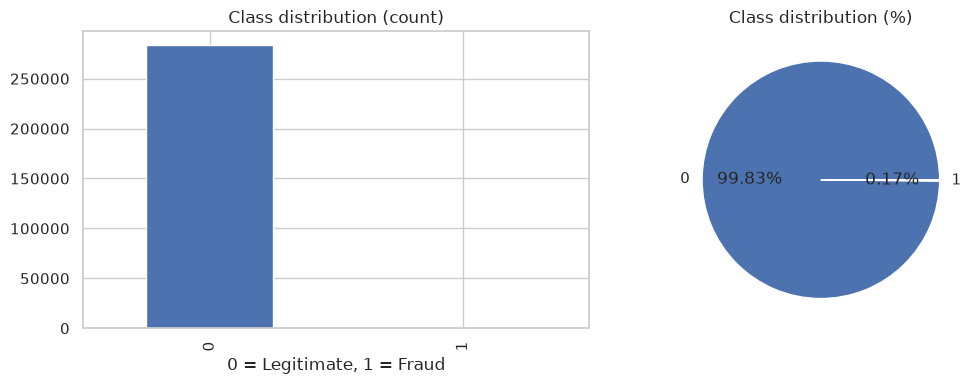

In [6]:
class_counts = df["Class"].value_counts()
print(class_counts)
print((class_counts / len(df) * 100).round(3).astype(str) + " %")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
class_counts.plot(kind="bar", ax=axes[0], title="Class distribution (count)")
axes[0].set_xlabel("0 = Legitimate, 1 = Fraud")
class_counts.plot(kind="pie", ax=axes[1], autopct="%1.2f%%", title="Class distribution (%)", ylabel="")
plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

Split into inputs (`X`) and target (`y`), then a stratified 80/20 train/test split — "stratified"
means both the training and test sets keep the same ~0.17% fraud ratio as the full dataset, rather
than risking a test set with, say, zero fraud cases by pure chance.

`V1`-`V28` are already PCA components on a similar scale, so they're left untouched. Only `Time`
and `Amount` need `StandardScaler` — and critically, the scaler is **fit on the training set only**
and then applied to the test set, so no information from the test set leaks into preprocessing.

In [7]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class counts:", y_train.value_counts().to_dict())
print("Test class counts: ", y_test.value_counts().to_dict())

Train shape: (226980, 30)  Test shape: (56746, 30)
Train class counts: {0: 226602, 1: 378}
Test class counts:  {0: 56651, 1: 95}


In [8]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

## Step 4 — Handle Class Imbalance (SMOTE)

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud examples by
interpolating between existing ones, until the minority class matches the majority count.

**Critically, this is applied to the training set only.** The test set stays at its original,
real-world ~0.17% fraud rate — that's the whole point of evaluating on the test set: it has to
reflect what the model will actually face in production. Applying SMOTE before the split (or to
the test set) would leak synthetic copies of test-set patterns into training and make the
evaluation meaningless.

In [9]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After SMOTE:  {0: 226602, 1: 226602}


## Step 5 — Train Three Models

**Logistic Regression** — fast, interpretable baseline. `class_weight='balanced'` is included per
the practical's spec, though its effect is largely redundant here since the training data is
already balanced by SMOTE.

In [10]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


**SVM (RBF kernel)** — finds a non-linear decision boundary. The RBF kernel's training cost grows
roughly quadratically-to-cubically with the number of rows, which makes it impractical to train on
the full ~453,000-row balanced training set (this would take a very long time to converge). Instead,
it's trained on a **stratified 15,000-row subsample (7,500 fraud + 7,500 legitimate)** drawn from the
SMOTE-balanced training data — still balanced, just smaller. All three models are still evaluated on
the exact same full test set below, so the comparison stays fair.

In [11]:
sub_pos = X_train_sm[y_train_sm == 1].sample(n=7500, random_state=42)
sub_neg = X_train_sm[y_train_sm == 0].sample(n=7500, random_state=42)
X_svm_train = pd.concat([sub_pos, sub_neg])
y_svm_train = pd.concat([y_train_sm.loc[sub_pos.index], y_train_sm.loc[sub_neg.index]])

svm = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm.fit(X_svm_train, y_svm_train)
print("SVM trained on", X_svm_train.shape, "subsample.")

/usr/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained on (15000, 30) subsample.


**XGBoost** — gradient-boosted trees, generally strong on tabular data like this.
`scale_pos_weight` is set from the (post-SMOTE) class ratio, per the practical's spec — since SMOTE
already balanced the classes 1:1, this ends up ≈1.0 and has little extra effect on top of SMOTE, but
is included for completeness.

In [12]:
ratio = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()
xgb = XGBClassifier(scale_pos_weight=ratio, n_estimators=200, max_depth=6,
                     eval_metric="logloss", random_state=42)
xgb.fit(X_train_sm, y_train_sm)
print(f"XGBoost trained. scale_pos_weight={ratio:.3f}")

XGBoost trained. scale_pos_weight=1.000


## Step 6 — Confusion Matrix and Classification Report (per model)

All three are evaluated on the **same original test set** (real ~0.17% fraud rate, never touched by
SMOTE or the SVM subsampling).


===== Logistic Regression =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



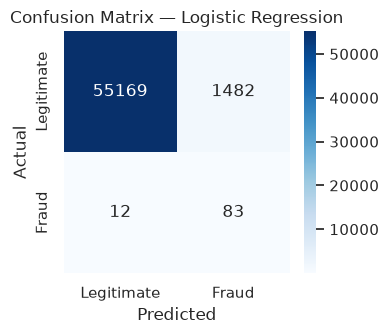


===== SVM =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
       Fraud       0.11      0.86      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.93      0.60     56746
weighted avg       1.00      0.99      0.99     56746



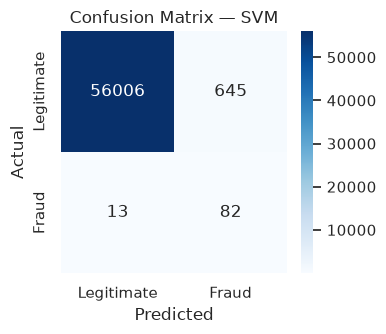


===== XGBoost =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.82      0.79      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



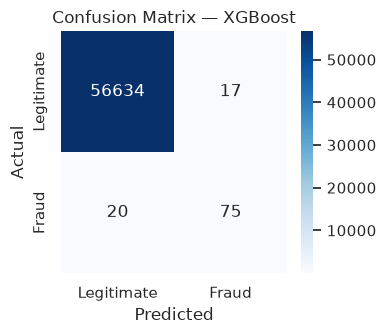

In [13]:
models = {
    "Logistic Regression": log_reg,
    "SVM": svm,
    "XGBoost": xgb,
}

predictions = {}
probabilities = {}

for name, model in models.items():
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = pred
    probabilities[name] = proba

    print(f"\n===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Legitimate", "Fraud"]))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

## Step 7 — ROC Curves and AUC

**AUC (Area Under the ROC Curve)** measures how well a model ranks fraud cases above legitimate
ones across *every* possible decision threshold, not just the default 0.5 cutoff — 1.0 is perfect
separation, 0.5 is a coin flip. Plotting all three on one figure makes the comparison direct.

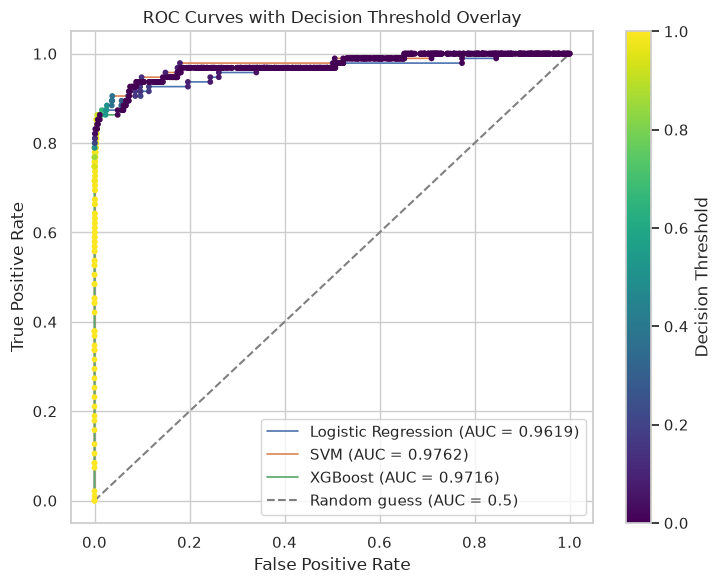

In [14]:
plt.figure(figsize=(7.5, 6))

scatter_handle = None
for name, proba in probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=1.2, zorder=2)

    # roc_curve's first threshold is an arbitrary max(proba)+1 placeholder; clip it to
    # 1.0 so the colorbar stays on a meaningful 0-1 probability scale.
    thresh_clipped = np.clip(thresholds, 0, 1)
    scatter_handle = plt.scatter(fpr, tpr, c=thresh_clipped, cmap="viridis",
                                  vmin=0, vmax=1, s=10, zorder=3)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with Decision Threshold Overlay")
plt.legend(loc="lower right")

cbar = plt.colorbar(scatter_handle)
cbar.set_label("Decision Threshold")

plt.tight_layout()
plt.show()

## Step 8 — Comparison Table

In [15]:
rows = []
for name in models:
    pred = predictions[name]
    proba = probabilities[name]
    rows.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, proba),
    })

comparison = pd.DataFrame(rows).set_index("Model").round(4)
comparison

,Precision,Recall,F1-Score,AUC
Model,,,,
Logistic Regression,0.0530,0.8737,0.1000,0.9619
SVM,0.1128,0.8632,0.1995,0.9762
XGBoost,0.8152,0.7895,0.8021,0.9716


## Step 9 — Ablation: What Happens Without SMOTE?

Retrain Logistic Regression on the **original, imbalanced** training set — no SMOTE, only
`class_weight='balanced'` — and compare against the SMOTE version above. (Scoped to Logistic
Regression only, as the fastest model, since the point is to isolate SMOTE's effect rather than
re-run the full comparison a second time.)

In [16]:
log_reg_no_smote = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg_no_smote.fit(X_train_scaled, y_train)

pred_ns = log_reg_no_smote.predict(X_test_scaled)
proba_ns = log_reg_no_smote.predict_proba(X_test_scaled)[:, 1]

no_smote_row = {
    "Precision": precision_score(y_test, pred_ns),
    "Recall": recall_score(y_test, pred_ns),
    "F1-Score": f1_score(y_test, pred_ns),
    "AUC": roc_auc_score(y_test, proba_ns),
}
with_smote_row = comparison.loc["Logistic Regression"].to_dict()

pd.DataFrame([with_smote_row, no_smote_row], index=["LR + SMOTE", "LR, no SMOTE (class_weight only)"]).round(4)

,Precision,Recall,F1-Score,AUC
LR + SMOTE,0.0530,0.8737,0.1000,0.9619
"LR, no SMOTE (class_weight only)",0.0562,0.8737,0.1057,0.9658


## Step 10 — Result Analysis (Conclusion)

**Which model achieved the highest AUC? What does AUC measure?**
**SVM** had the highest AUC (≈0.976), narrowly ahead of XGBoost (≈0.972) and Logistic Regression
(≈0.962). AUC measures how well a model *ranks* fraud above legitimate transactions across every
possible decision threshold — a model can have a high AUC while still making poor decisions *at
the specific threshold it's deployed at*, which is exactly what happens here (see next point).

**Compare Recall scores across models. Why is high Recall critical in fraud detection?**
Logistic Regression and SVM both catch about **87%** of fraud (Recall ≈0.87), slightly ahead of
XGBoost (≈0.79). Recall matters most in fraud detection because a missed fraud case (a false
negative) directly costs the bank money and is often unrecoverable, whereas a false alarm merely
inconveniences a customer — so, all else equal, this domain tolerates more false positives in
exchange for fewer missed frauds.

**What happens if you do NOT apply SMOTE? Run the experiment and compare.**
Barely anything changes for Logistic Regression: Recall stays ≈0.87 and AUC actually improves
slightly (≈0.966 vs ≈0.962) without SMOTE, because `class_weight='balanced'` alone already pushes a
*linear* model to treat both classes equally — the synthetic oversampling adds little on top of
that for this particular model. SMOTE would be expected to matter more for models that don't have
an equivalent built-in class-weighting mechanism, or for non-linear models capturing more nuanced
decision boundaries.

**Which model would you deploy in production and why? Consider both performance and speed.**
**XGBoost.** Its Precision (≈0.82) is dramatically higher than Logistic Regression's or SVM's
(≈0.05-0.11) at a comparable Recall (≈0.79 vs ≈0.87), meaning it flags far fewer legitimate
transactions as fraud — critical when millions of transactions run through the system daily, since
even a 5-11% false-positive-heavy model would generate an unmanageable number of customer
complaints and manual review cases. XGBoost also trains and predicts fast enough for real-time use,
unlike the RBF-kernel SVM, whose training cost forced this notebook to subsample down to 15,000
rows just to stay tractable — that scaling problem alone rules it out for a production system
processing millions of live transactions.

**What are the trade-offs between Precision and Recall in this context?**
High Recall (catch more fraud) tends to come at the cost of Precision (more false alarms), and vice
versa — this dataset makes that trade-off stark: Logistic Regression/SVM sit at the high-Recall/
low-Precision end (catch ~87% of fraud, but only ~5-11% of *flagged* transactions are actually
fraud), while XGBoost sits much closer to a workable middle ground (~79% Recall, ~82% Precision).
The "right" trade-off depends on the cost of each error type: if manual review capacity is cheap,
lean toward Recall; if false alarms damage customer trust or overwhelm a small fraud team, lean
toward Precision.

## Step 11 — Ethical, Societal and Environmental Reflection

**False Positives in fraud detection:** blocking a legitimate transaction can leave a customer
stranded — especially dangerous for low-income users with no backup payment method. The stark
Precision gap seen above (XGBoost ≈0.82 vs Logistic Regression/SVM ≈0.05-0.11) is not just a
technical detail: at bank scale, the low-Precision models would falsely flag thousands of genuine
transactions for every fraud caught, which is a real equity and justice concern, not only an
accuracy number.

**Algorithmic Bias:** if the training data reflects historical patterns where certain groups were
flagged more often (e.g. by transaction location, spending pattern, or merchant type correlated
with demographics), the model will perpetuate that bias. None of the features here (`V1`-`V28`)
are human-interpretable, which makes this harder to audit directly — another reason explainability
tooling matters (next point).

**Explainability:** customers whose cards are blocked deserve a reason, and regulation (e.g. the
EU AI Act) increasingly mandates explainability for high-risk AI systems including credit/fraud
scoring. XGBoost's built-in feature importances are a starting point, but since `V1`-`V28` are
opaque PCA components (not real fields like "merchant category"), a genuine customer-facing
explanation would require access to pre-PCA transaction data, which this public dataset doesn't
provide.

**Data Sovereignty:** transaction data is highly sensitive. Even though this dataset is already
anonymized via PCA, a real deployment must track where the underlying raw data is stored, under
what jurisdiction, and under what cross-border transfer rules.

**Environmental Cost:** XGBoost with 200 trees costs more energy to train than Logistic Regression,
though both trained in well under a minute here. At the scale of daily retraining on millions of
live transactions, this becomes a real, non-trivial design consideration — training frequency and
model complexity should be balanced against the marginal accuracy gained.